## Individual Preprocessing Technique: Duplicate Removal & Class Imbalance Analysis
**Member:** Lakshan H.M.K | IT25101220

**Dataset:** Adult Income Dataset (UCI Machine Learning Repository)

**Topic:** Duplicate Removal + Class Imbalance Analysis

**Purpose:** Detect and eliminate exact duplicate records to prevent data leakage and sample redundancy, and validate the target variable (`income`) distribution to quantify class imbalance.

## Common Pipeline Prerequisites
### Shared group setup – not this member's individual contribution

The following setup represents shared group initialization required for data loading and string normalization.


In [9]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set consistent plotting styles
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['font.family'] = 'sans-serif'

# Define directory paths
possible_paths = [
    Path('../data/raw/adult.csv'),
    Path('../data/adult.csv'),
    Path('adult.csv'),
    Path('../../ML Project/adult-income-random-forest/data/raw/adult.csv'),
    Path('../../ML Project/adult.csv')
]
DATA_RAW_PATH = next((p for p in possible_paths if p.exists()), Path('adult.csv'))
OUTPUT_FIGURES_DIR = Path('../results/eda_visualizations')
os.makedirs(OUTPUT_FIGURES_DIR, exist_ok=True)

# 1. Load Raw Dataset
df_raw = pd.read_csv(DATA_RAW_PATH)
df = df_raw.copy()
print(f"Loaded dataset from: {DATA_RAW_PATH}")
print(f"Raw dataset successfully loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

# 2. Strip leading/trailing whitespace from string columns
str_cols = df.select_dtypes(include=['object', 'string']).columns
for col in str_cols:
    df[col] = df[col].astype(str).str.strip()
print(f"Categorical string whitespace stripped across {len(str_cols)} columns.")


Loaded dataset from: ..\data\raw\adult.csv
Raw dataset successfully loaded: 32,561 rows, 15 columns
Categorical string whitespace stripped across 9 columns.


# Individual Contribution
## Duplicate Detection & Removal and Target Class Imbalance Analysis
**Contributor:** Lakshan H.M.K | IT25101220


### 1. Exact Duplicate Detection & Removal
Exact duplicate rows represent repeated records across all 15 recorded dataset columns, including the target. If left in the dataset, duplicates can artificially inflate model confidence or leak identical records across train and test partitions.


In [10]:
# 1. Inspect duplicate counts before removal
rows_before = len(df)
duplicate_mask = df.duplicated()
duplicate_count = duplicate_mask.sum()

print(f"Raw dataset rows (rows_before): {rows_before:,}")
print(f"Exact duplicate rows detected:   {duplicate_count:,}")

# Display sample duplicated rows
if duplicate_count > 0:
    print("\nSample Duplicated Records (first 4 duplicates):")
    display(df[duplicate_mask].head(4))

# 2. Drop exact duplicates
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
rows_after = len(df)

print(f"\nCleaned dataset rows (rows_after): {rows_after:,}")
print(f"Verification: {rows_before:,} - {duplicate_count:,} = {rows_after:,} (Match: {rows_before - duplicate_count == rows_after})")

# Summary Table
dup_summary_df = pd.DataFrame({
    'Metric': ['Raw Rows', 'Exact Duplicates Removed', 'Cleaned Unique Rows'],
    'Count': [f"{rows_before:,}", f"{duplicate_count:,}", f"{rows_after:,}"]
})
display(dup_summary_df)


Raw dataset rows (rows_before): 32,561
Exact duplicate rows detected:   24

Sample Duplicated Records (first 4 duplicates):


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
8453,25,Private,308144,Bachelors,13,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,Mexico,<=50K
8645,90,Private,52386,Some-college,10,Never-married,Other-service,Not-in-family,Asian-Pac-Islander,Male,0,0,35,United-States,<=50K
12202,21,Private,250051,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,10,United-States,<=50K
14346,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K



Cleaned dataset rows (rows_after): 32,537
Verification: 32,561 - 24 = 32,537 (Match: True)


,Metric,Count
0,Raw Rows,"32,561"
1,Exact Duplicates Removed,24
2,Cleaned Unique Rows,"32,537"


### 2. Target Variable Validation (`income`) & Class Imbalance Analysis
Inspect the target variable `income` on the cleaned dataset ($N=32,537$) to evaluate class distribution and measure class imbalance.


In [11]:
# 1. Target class counts and percentages
target_counts = df['income'].value_counts()
target_pct = df['income'].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    'Income Class': target_counts.index,
    'Observation Count': target_counts.values,
    'Proportion (%)': target_pct.values
})

print("=== Target Class Distribution Table (Cleaned N = 32,537) ===")
display(target_summary)

imbalance_ratio = target_counts['<=50K'] / target_counts['>50K']
print(f"Class Imbalance Ratio (<=50K : >50K): {imbalance_ratio:.2f} : 1")


=== Target Class Distribution Table (Cleaned N = 32,537) ===


,Income Class,Observation Count,Proportion (%)
0,<=50K,24698,75.907428
1,>50K,7839,24.092572


Class Imbalance Ratio (<=50K : >50K): 3.15 : 1


### 3. Target Class Distribution Visualization
Generate a clear bar chart illustrating the class imbalance between `<=50K` and `>50K`.


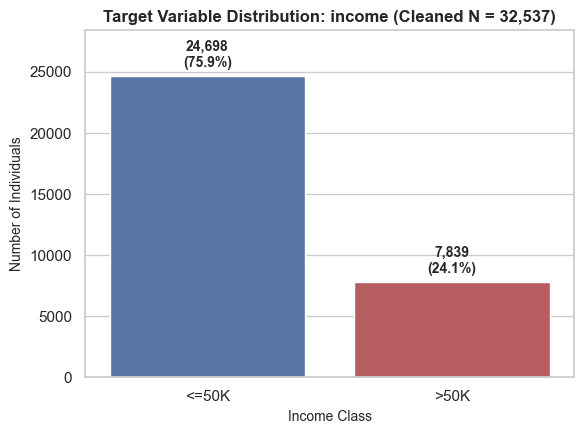

Saved figure: results/eda_visualizations/IT25101220_Duplicate_Class_Imbalance_Distribution.png


In [12]:
plt.figure(figsize=(6, 4.5))
palette_colors = {'<=50K': '#4C72B0', '>50K': '#C44E52'}
ax = sns.countplot(
    data=df,
    x='income',
    order=['<=50K', '>50K'],
    hue='income',
    palette=palette_colors,
    legend=False
)

plt.title('Target Variable Distribution: income (Cleaned N = 32,537)', fontsize=12, fontweight='bold')
plt.xlabel('Income Class', fontsize=10)
plt.ylabel('Number of Individuals', fontsize=10)
plt.ylim(0, max(target_counts.values) * 1.15)

# Annotate bars with counts and percentages
total_n = len(df)
for p in ax.patches:
    height = int(p.get_height())
    pct = (height / total_n) * 100
    ax.annotate(
        f"{height:,}\n({pct:.1f}%)",
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom',
        fontsize=10,
        fontweight='bold',
        xytext=(0, 4),
        textcoords='offset points'
    )

plt.tight_layout()
FIGURE_PATH = OUTPUT_FIGURES_DIR / 'IT25101220_Duplicate_Class_Imbalance_Distribution.png'
plt.savefig(FIGURE_PATH, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved figure: {FIGURE_PATH.resolve()}")


### EDA Interpretation

After removing 24 exact duplicate rows, 24,698 of the 32,537 remaining records (75.9%) belong to the `<=50K` class and 7,839 (24.1%) belong to the `>50K` class. The chart shows that the lower-income class is about 3.15 times as common. This imbalance matters because a model could achieve high overall accuracy while predicting the minority `>50K` class poorly. The group pipeline should preserve class proportions when splitting the data and report class-sensitive metrics such as precision, recall, and F1-score.
